# Plot [Fig. 3]PDF(R/R200c), [Fig. 5]stellar mass distribution, [Fig. 6]Quenched Fraction, [Fig. 7]PDF_lowmass(R/R200c)
## Runtime: 59s

In [1]:
import numpy as np

from scipy.linalg import eigh
from scipy.stats import zscore
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle
from matplotlib.patches import FancyArrowPatch

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import h5py

from sklearn.decomposition import PCA

import glob

import os

from tqdm import tqdm

import sys
sys.path.append("/home/zhangzhuoming/Quench_Direction") 
from ellip_axis_finder import Compute_Distances_Numba
from ellip_axis_finder import Sphere_Sampling_Method
from ellip_axis_finder import Inertia_Tensor_Method
from correct_periodic_coords import Correct_Periodic_Coords

import pickle

In [2]:
def Load_Catalog(file_path_catalog):
    """
    Load EAGLE galaxy/halo catalog HDF5 file, return a dictionary containing all data

    Parameters:
        file_path_catalog (str): Full path to the HDF5 catalog file

    Returns:
        dict: Dictionary storing galaxy and halo data, accessible via keys
              e.g., data['halo_mass'], data['star_mass']
    """
    # Initialize empty dictionary for data storage
    data = {}
    
    with h5py.File(file_path_catalog, 'r') as f:
        # ===================== Galaxy data galaxy_data =====================
        data['GroupID'] = f['galaxy_data/GroupID'][:]
        data['parent_halo_index'] = f['galaxy_data/parent_halo_index'][:]
        data['central'] = f['galaxy_data/central'][:]
        data['pos'] = f['galaxy_data/pos'][:]  # kpc
        # data['vel'] = f['galaxy_data/vel'][:]  # Uncomment if needed
        
        # Scalar / array quantities
        data['sfr'] = f['galaxy_data/sfr'][()]
        
        # Sub-dataset for galaxy properties
        dicts = f['galaxy_data/dicts']
        data['star_mass'] = dicts['masses.stellar'][:]
        # Sub-dataset for halo properties
        halo_dicts = f['halo_data/dicts']
        data['halo_r200c'] = halo_dicts['virial_quantities.r200c'][:]  # kpc
        data['halo_m200c'] = halo_dicts['virial_quantities.m200c'][:]
        
    return data

In [3]:
file_path_EAGLE = '/data/inspur_disk01/userdir/zhangzhuoming/EAGLE/galaxy_catalogs/Caesar_RefL0100N1504-FoF.hdf5'
DATA_EAGLE = Load_Catalog(file_path_EAGLE)

file_path_TNG100 = '/data/inspur_disk01/userdir/zhangzhuoming/TNG100/galaxy_catalogs/Caesar_TNG_100.hdf5'
DATA_TNG100 = Load_Catalog(file_path_TNG100)

file_path_SIMBAs50nofb = '/data/inspur_disk06/userdir/zhangzhuoming/Simba/galaxy_catalogs_nofb/m50n512_151.hdf5'
DATA_SIMBAs50nofb = Load_Catalog(file_path_SIMBAs50nofb)

file_path_SIMBA = '/data/inspur_disk06/userdir/zhangzhuoming/Simba/galaxy_catalogs/m100n1024_151.hdf5'
DATA_SIMBA = Load_Catalog(file_path_SIMBA)

In [4]:
star_mass_EAGLE = DATA_EAGLE['star_mass']

star_mass_TNG100 = DATA_TNG100['star_mass']

star_mass_SIMBAs50nofb = DATA_SIMBAs50nofb['star_mass']

star_mass_SIMBA = DATA_SIMBA['star_mass']

In [5]:
def Mass_Function(mass_array, bins=20):

    mass_valid = mass_array[mass_array > 0]
    log_mass = np.log10(mass_valid)
    
    hist, edges = np.histogram(log_mass, bins=bins)
    mass_mid = 0.5 * (edges[1:] + edges[:-1])
    
    with np.errstate(divide='ignore'):
        log_counts = np.log10(hist)
    
    return mass_mid, log_counts, edges

In [6]:
def Classify_Galaxies_By_SFR_Mstar(star_mass, sfr, redshift=0.0):
    SF = []
    GV = []
    Q = []
    
    for m, s in zip(star_mass, sfr):
        if m <= 0:
            continue
        
        log_m = np.log10(m)
        log_s = np.log10(s) if s > 0 else -np.inf
        threshold = 0.73 * log_m - 7.33 + np.log10((1 + redshift)**2)
        threshold_q = threshold - 1
        
        if s > 0 and log_s > threshold:
            SF.append((m, s))
        elif s > 0 and threshold_q < log_s < threshold:
            GV.append((m, s))
        else:
            Q.append((m, s))
    
    m_SF = np.array([x[0] for x in SF])
    m_GV = np.array([x[0] for x in GV])
    m_Q  = np.array([x[0] for x in Q])
    return m_SF, m_GV, m_Q

# [Fig. 5]stellar mass distribution

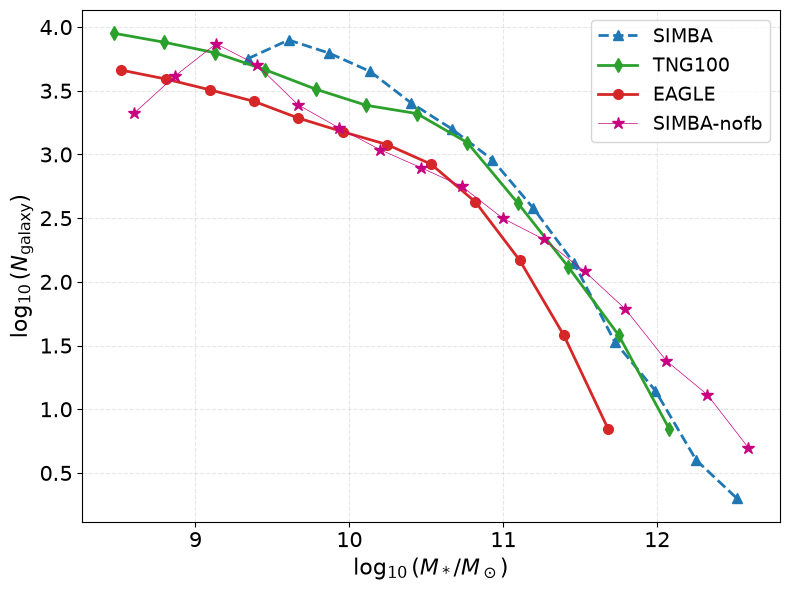

In [7]:
star_mass_mid_EAGLE, star_mass_cnt_EAGLE, _ = Mass_Function(star_mass_EAGLE, bins=16)
star_mass_mid_TNG100, star_mass_cnt_TNG100, _ = Mass_Function(star_mass_TNG100, bins=16)
star_mass_mid_SIMBAs50nofb, star_mass_cnt_SIMBAs50nofb, _ = Mass_Function(star_mass_SIMBAs50nofb, bins=16)
star_mass_mid_SIMBA, star_mass_cnt_SIMBA, _ = Mass_Function(star_mass_SIMBA, bins=16)

# ===================== Plotting =====================
plt.figure(figsize=(8, 6))

# ========== SIMBA: plot starting from x = np.log10(100 * 1.82 * 1e7)
x_th_SIMBA = np.log10(100 * 1.82 * 1e7)
mask_SIMBA = star_mass_mid_SIMBA >= x_th_SIMBA
plt.plot(star_mass_mid_SIMBA[mask_SIMBA], star_mass_cnt_SIMBA[mask_SIMBA],
         color="#1f77b4", marker='^', linestyle='--', 
         linewidth=2, markersize=7, label='SIMBA')

# ========== TNG100: plot starting from x = np.log10(100 * 1.40 * 1e6)
x_th_TNG100 = np.log10(100 * 1.40 * 1e6)
mask_TNG100 = star_mass_mid_TNG100 >= x_th_TNG100
plt.plot(star_mass_mid_TNG100[mask_TNG100], star_mass_cnt_TNG100[mask_TNG100],
         color="#2ca02c", marker='d', linestyle='-', 
         linewidth=2, markersize=7, label='TNG100')

# ========== EAGLE: plot starting from x = np.log10(100 * 1.81 * 1e6)
x_th_EAGLE = np.log10(100 * 1.81 * 1e6)
mask_EAGLE = star_mass_mid_EAGLE >= x_th_EAGLE
plt.plot(star_mass_mid_EAGLE[mask_EAGLE], star_mass_cnt_EAGLE[mask_EAGLE],
         color="#d62728", marker='o', linestyle='-', 
         linewidth=2, markersize=7, label='EAGLE')

# ========== SIMBAs50nofb: plot starting from x = np.log10(100 * 2.28 * 1e6)
x_th_SIMBAs50nofb = np.log10(100 * 2.28 * 1e6)
mask_SIMBAs50nofb = star_mass_mid_SIMBAs50nofb >= x_th_SIMBAs50nofb
plt.plot(star_mass_mid_SIMBAs50nofb[mask_SIMBAs50nofb], star_mass_cnt_SIMBAs50nofb[mask_SIMBAs50nofb],
         color="#c80080", marker='*', linestyle='-', 
         linewidth=0.5, markersize=9, label='SIMBA-nofb')

# ===================== Style settings =====================
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel(r'$\log_{10}(M_* / M_\odot)$', fontsize=16)
plt.ylabel(r'$\log_{10}({N_\mathrm{galaxy}})$', fontsize=16)
plt.legend(fontsize=14)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('fig_result/starmass_function.pdf')
# Show the figure
plt.show()

# [Fig. 6]Quenched Fraction

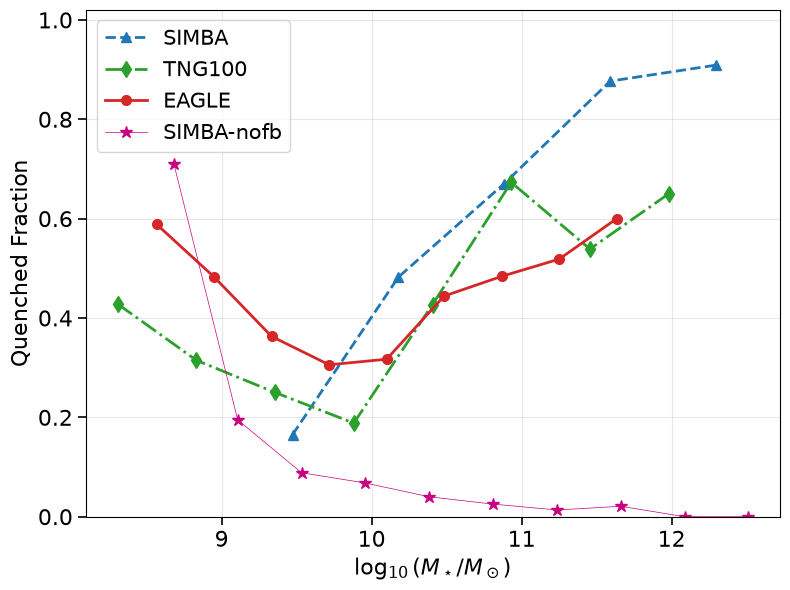

In [8]:
# All galaxies
m_mid_E, log_tot_E, edges_EAGLE = Mass_Function(DATA_EAGLE['star_mass'], bins=12)
m_mid_TNG100, log_tot_TNG100, edges_TNG100 = Mass_Function(DATA_TNG100['star_mass'], bins=10)
m_mid_SIMBAs50nofb, log_tot_SIMBAs50nofb, edges_SIMBAs50nofb = Mass_Function(DATA_SIMBAs50nofb['star_mass'], bins=10)
m_mid_SIMBA, log_tot_SIMBA, edges_SIMBA = Mass_Function(DATA_SIMBA['star_mass'], bins=6)

# Classify galaxies: Star-forming / Green Valley / Quenched
m_SF_E, m_GV_E, m_Q_E = Classify_Galaxies_By_SFR_Mstar(DATA_EAGLE['star_mass'], DATA_EAGLE['sfr'])
m_SF_TNG100, m_GV_TNG100, m_Q_TNG100 = Classify_Galaxies_By_SFR_Mstar(DATA_TNG100['star_mass'], DATA_TNG100['sfr'])
m_SF_SIMBAs50nofb, m_GV_SIMBAs50nofb, m_Q_SIMBAs50nofb = Classify_Galaxies_By_SFR_Mstar(DATA_SIMBAs50nofb['star_mass'], DATA_SIMBAs50nofb['sfr'])
m_SF_SIMBA, m_GV_SIMBA, m_Q_SIMBA = Classify_Galaxies_By_SFR_Mstar(DATA_SIMBA['star_mass'], DATA_SIMBA['sfr'])

# Mass functions for classified galaxy populations (using shared bin edges for each simulation)
mid_SF_SIMBA, log_SF_SIMBA, _ = Mass_Function(m_SF_SIMBA, bins=edges_SIMBA)
mid_GV_SIMBA, log_GV_SIMBA, _ = Mass_Function(m_GV_SIMBA, bins=edges_SIMBA)
mid_Q_SIMBA, log_Q_SIMBA, _ = Mass_Function(m_Q_SIMBA, bins=edges_SIMBA)

mid_SF_SIMBAs50nofb, log_SF_SIMBAs50nofb, _ = Mass_Function(m_SF_SIMBAs50nofb, bins=edges_SIMBAs50nofb)
mid_GV_SIMBAs50nofb, log_GV_SIMBAs50nofb, _ = Mass_Function(m_GV_SIMBAs50nofb, bins=edges_SIMBAs50nofb)
mid_Q_SIMBAs50nofb, log_Q_SIMBAs50nofb, _ = Mass_Function(m_Q_SIMBAs50nofb, bins=edges_SIMBAs50nofb)

mid_SF_E, log_SF_E, _ = Mass_Function(m_SF_E, bins=edges_EAGLE)
mid_GV_E, log_GV_E, _ = Mass_Function(m_GV_E, bins=edges_EAGLE)
mid_Q_E, log_Q_E, _ = Mass_Function(m_Q_E, bins=edges_EAGLE)

mid_SF_TNG100, log_SF_TNG100, _ = Mass_Function(m_SF_TNG100, bins=edges_TNG100)
mid_GV_TNG100, log_GV_TNG100, _ = Mass_Function(m_GV_TNG100, bins=edges_TNG100)
mid_Q_TNG100, log_Q_TNG100, _ = Mass_Function(m_Q_TNG100, bins=edges_TNG100)

# ==========================================
col_SF = '#1f77b4'
col_GV = '#2ca02c'
col_Q  = '#d62728'
col_total = 'black'
lw, ms = 2, 7

# EAGLE line style
style_EAGLE       = 'o-'
# TNG100 line style
style_TNG100       = 'd-.'
# SIMBA s50 full line style
style_SIMBAs50full= 's:'
# SIMBA s50 no-feedback line style
style_SIMBAs50nofb= '*-'
# SIMBA line style
style_SIMBA       = '^--'
# ======================================================================
plt.figure(figsize=(8, 6))
ax2 = plt.gca()

# Mass plotting range for each simulation
range_SIMBA    = (np.log10(1.82*1e9), 15.0)
range_SIMBAs50 = (np.log10(2.28*1e8), 15.0) 
range_SIMBAs50nofb = (np.log10(2.28*1e8), 15.0)    
range_EAGLE    = (np.log10(1.81*1e8), 15.0)    
range_TNG100   = (np.log10(1.40*1e8), 15.5)    
# ======================================================================

# Suppress runtime warnings for division and invalid values
with np.errstate(divide='ignore', invalid='ignore'):
    # SIMBA
    x, y = mid_Q_SIMBA, 10**log_Q_SIMBA / 10**log_tot_SIMBA
    mask = (x >= range_SIMBA[0]) & (x <= range_SIMBA[1])
    ax2.plot(x[mask], y[mask], 
             color='#1f77b4', marker='^', linestyle='--', lw=lw, ms=ms, label='SIMBA')
    
    # TNG100
    x, y = mid_Q_TNG100, 10**log_Q_TNG100 / 10**log_tot_TNG100
    mask = (x >= range_TNG100[0]) & (x <= range_TNG100[1])
    ax2.plot(x[mask], y[mask], 
             color='#2ca02c', marker='d', linestyle='-.', lw=lw, ms=8, label='TNG100')
    
    # EAGLE
    x, y = mid_Q_E, 10**log_Q_E / 10**log_tot_E
    mask = (x >= range_EAGLE[0]) & (x <= range_EAGLE[1])
    ax2.plot(x[mask], y[mask], 
             color='#d62728', marker='o', linestyle='-', lw=lw, ms=ms, label='EAGLE')
    
    # SIMBA s50 no-feedback
    x, y = mid_Q_SIMBAs50nofb, 10**log_Q_SIMBAs50nofb / 10**log_tot_SIMBAs50nofb
    mask = (x >= range_SIMBAs50nofb[0]) & (x <= range_SIMBAs50nofb[1])
    ax2.plot(x[mask], y[mask], 
             color='#c80080', marker='*', linestyle='-', lw=0.5, ms=9, label='SIMBA-nofb')
    
ax2.set_xlabel(r'$\log_{10}(M_\star / M_\odot)$', fontsize=16)
ax2.set_ylabel(r'Quenched Fraction', fontsize=16)
ax2.tick_params(axis='both', labelsize=16, length=6, width=1.2)
ax2.set_ylim(0, 1.02)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=15, loc='best', frameon=True)
plt.tight_layout()
plt.savefig('fig_result/F_Q.pdf')
plt.show()

# Radius distribution of quenched Galaxies and unquenched Galaxies in four simulations

In [9]:
def UnQ_Q_Selection(sgaldata):
    """
    Select unquenched and quenched galaxies based on the SFR-$M_*$ dividing criterion,
    then sample galaxies inside cones along major/minor axes and return the selected samples.
    """
    UnQgal = []
    Qgal = []
    for i in range(len(sgaldata)):
        # Unquenched galaxy selection criterion
        if (sgaldata[i][6] != 0) and (np.log10(sgaldata[i][6]) > (0.73 * np.log10(sgaldata[i][7]) - 7.33 - 1 + np.log10((1 + redshift)**2))):
            UnQgal.append(sgaldata[i][:])    
        # Quenched galaxy selection criterion
        if (sgaldata[i][6] == 0) or (np.log10(sgaldata[i][6]) < (0.73 * np.log10(sgaldata[i][7]) - 7.33 - 1 + np.log10((1 + redshift)**2))):
            Qgal.append(sgaldata[i][:])
            
    # Convert list of unquenched galaxies to numpy array
    if UnQgal:
        UnQgal_arr = np.vstack(UnQgal)
    else:
        UnQgal_arr = np.array([])
    # Convert list of quenched galaxies to numpy array
    if Qgal:
        Qgal_arr = np.vstack(Qgal)
    else:
        Qgal_arr = np.array([])
        
    orient_angle = 30
    orient = np.linspace(0, 360, int((360/orient_angle)+1))
    x = np.cos(np.radians(orient))
    y = np.zeros(len(orient))
    z = np.sin(np.radians(orient))
    orient_vec = np.column_stack((x, y, z))
    
    # Initialize lists to store galaxies inside each cone for unquenched and quenched samples
    UnQinside_cone = [[] for _ in range(len(orient_vec))]
    Qinside_cone = [[] for _ in range(len(orient_vec))]
    
    # Loop over all cone orientation vectors for unquenched galaxies
    for i in range(len(orient_vec)):
        for j in range(UnQgal_arr.shape[0]):
            # Compute dot product between galaxy position and cone axis vector
            dot_products = np.dot(UnQgal_arr[j, 0:3], orient_vec[i])
            # Compute angle between position vector and cone axis (radians)
            angles = np.arccos(dot_products / (np.linalg.norm(orient_vec[i]) * np.linalg.norm(UnQgal_arr[j, 0:3,])))
            # Convert angle from radians to degrees
            angles_deg = np.degrees(angles)
            # Keep galaxies within the cone opening angle
            if (angles_deg < sample_angle):
                UnQinside_cone[i].append(UnQgal_arr[j, :])
        # Convert list to array if any galaxies are found in this cone
        if UnQinside_cone[i]:
            UnQinside_cone[i] = np.vstack(UnQinside_cone[i])
        else:
            UnQinside_cone[i] = np.empty((0, sgaldata[0].shape[0]))
            
    # Loop over all cone orientation vectors for quenched galaxies
    for i in range(len(orient_vec)):
        for j in range(Qgal_arr.shape[0]):
            # Compute dot product between galaxy position and cone axis vector
            dot_products = np.dot(Qgal_arr[j, 0:3], orient_vec[i])
            # Compute angle between position vector and cone axis (radians)
            angles = np.arccos(dot_products / (np.linalg.norm(orient_vec[i]) * np.linalg.norm(Qgal_arr[j, 0:3,])))
            # Convert angle from radians to degrees
            angles_deg = np.degrees(angles)
            # Keep galaxies within the cone opening angle
            if (angles_deg < sample_angle):
                Qinside_cone[i].append(Qgal_arr[j, :])
        # Convert list to array if any galaxies are found in this cone
        if Qinside_cone[i]:
            Qinside_cone[i] = np.vstack(Qinside_cone[i])
        else:
            Qinside_cone[i] = np.empty((0, sgaldata[0].shape[0]))
    
    # Combine cones along major axis directions
    UnQgal_major = np.vstack([UnQinside_cone[0], UnQinside_cone[6]])
    # Combine cones along minor axis directions
    UnQgal_minor = np.vstack([UnQinside_cone[3], UnQinside_cone[9]])
    
    Qgal_major = np.vstack([Qinside_cone[0], Qinside_cone[6]])
    Qgal_minor = np.vstack([Qinside_cone[3], Qinside_cone[9]])
    
    return UnQgal_major, UnQgal_minor, Qgal_major, Qgal_minor

In [10]:
def plot_distribution_with_uncertainty(
    data_list,          # Input data: list of 50 elements, each is a 1D array of ratios
    bins,               # Shared bin edges
    color,              # Line color
    marker,             # Marker style: e.g., 'o' or '*'
    linestyle='-',      # Line style: solid / dashed, etc.
    label='',
    markersize=6
):
    """
    Plot 50 faint sample realisations, the median profile, and the 99.7% percentile error band.
    Returns: bin centres, median values, lower percentile (0.15%), upper percentile (99.85%)
    """
    counts_list = []
    
    for arr in data_list:
        counts, _ = np.histogram(arr, bins=bins, density=True)
        counts_list.append(counts)
    
    counts_array = np.array(counts_list)  # shape (50, n_bins)
    
    # Percentile range: 0.15% -- 99.85%
    median = np.median(counts_array, axis=0)
    lower = np.percentile(counts_array, 0.15, axis=0)
    upper = np.percentile(counts_array, 99.85, axis=0)
    
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    plt.plot(
        bin_centers, median,
        color=color, linestyle=linestyle, linewidth=2.5,
        marker=marker, markersize=markersize, label=label
    )
    
    # 99.7% percentile error band
    plt.fill_between(bin_centers, lower, upper, color=color, alpha=0.2)
    
    return bin_centers, median, lower, upper


# [Fig. 3]SIMBA

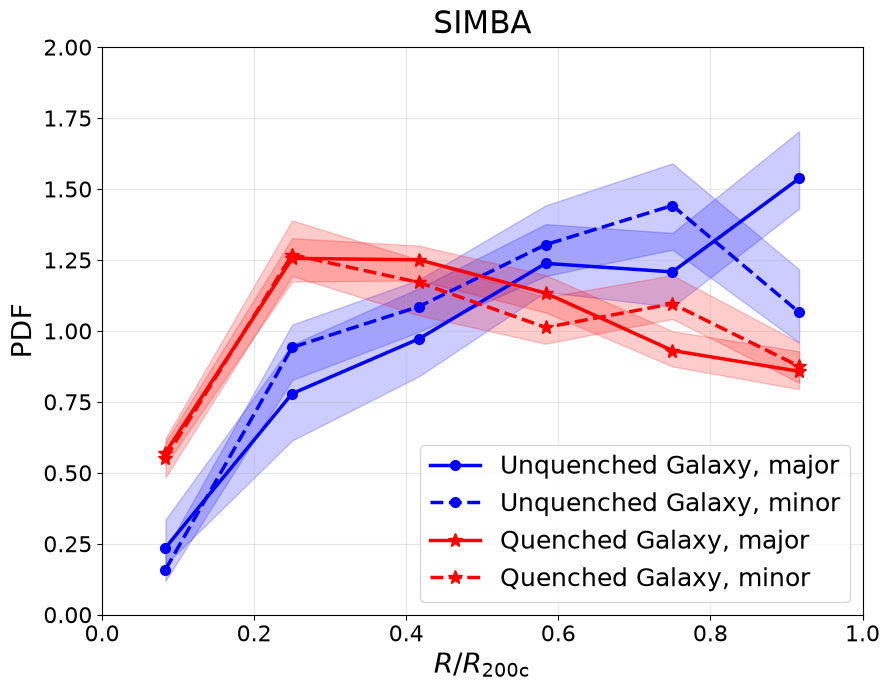

In [11]:
part_type = 'star_axis'

ITM = False
N_load = 50
sample_angle = 45 # [deg]
redshift = 0.0

snapnum = 151

UnQgal_major_collection = []
UnQgal_minor_collection = []

Qgal_major_collection = []
Qgal_minor_collection = []

for suffix in range(N_load):
    Full_snap = np.load('/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/SIMBAm100n1024/data/GalInHalo_' + part_type + f'/{snapnum:03}/galaxy_' + f'{suffix}' + '.npy')

    mask_cgal = Full_snap[:, 8] == Full_snap[:, 9]
    cgal_data = Full_snap[mask_cgal, :]
    mask_cgal_M200c = (cgal_data[:, 32] >= 1e12)
    mask_cgal_M = mask_cgal_M200c
    cgal_M_data = cgal_data[mask_cgal_M, :]

    with open(f'cluster_data/SIMBA/{snapnum:03}/all' + f'_data.pkl', 'rb') as f:
        axis_align_data = pickle.load(f)

    # cgalCID, [angle_1, angle_2, angle_3], vec_star(3*3), vec_dm(3*3)
    cgal_axis_state = np.array([sublist[0] for sublist in axis_align_data])

    mask_axis_state = np.isin(cgal_M_data[:, 9], cgal_axis_state)
    cgal_M_data = cgal_M_data[mask_axis_state]

    mask_sgal = np.isin(Full_snap[:, 9], cgal_M_data[:, 9]) & (Full_snap[:, 8] != Full_snap[:, 9]) & (Full_snap[:, 7] >= 10**(9.5)) & (Full_snap[:, 3] < Full_snap[:, 17])
    sgaldata = Full_snap[mask_sgal, :]

    UnQgal_major, UnQgal_minor, Qgal_major, Qgal_minor = UnQ_Q_Selection(sgaldata)
    
    UnQgal_major_collection.append(UnQgal_major)
    UnQgal_minor_collection.append(UnQgal_minor)
    
    Qgal_major_collection.append(Qgal_major)
    Qgal_minor_collection.append(Qgal_minor)
    

UnQgal_major_RR200c = []
for arr in UnQgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_major_RR200c.append(ratio)

UnQgal_minor_RR200c = []
for arr in UnQgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_minor_RR200c.append(ratio)

Qgal_major_RR200c = []
for arr in Qgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_major_RR200c.append(ratio)

Qgal_minor_RR200c = []
for arr in Qgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_minor_RR200c.append(ratio)
    
    
    
bins = np.linspace(0, 1, 7)

plt.figure(figsize=(9, 7))

# === 1. UnQgal_major_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_major_RR200c, bins,
    color='blue', marker='o', linestyle='-',
    markersize=7, label='Unquenched Galaxy, major'
)

# === 2. UnQgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_minor_RR200c, bins,
    color='blue', marker='o', linestyle='--',
    markersize=7, label='Unquenched Galaxy, minor'
)

# === 3. Qgal_major_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_major_RR200c, bins,
    color='red', marker='*', linestyle='-',
    markersize=10, label='Quenched Galaxy, major'
)

# === 4. Qgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_minor_RR200c, bins,
    color='red', marker='*', linestyle='--',
    markersize=10, label='Quenched Galaxy, minor'
)

plt.xlim(0, 1)
plt.ylim(0, 2)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel(r'$R/R_\mathrm{200c}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.title('SIMBA', fontsize=22, pad=10)
plt.legend(fontsize=18, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_result/SIMBA_UnQ_Q_R.pdf')
plt.show()

# [Fig. 3]SIMBAs50

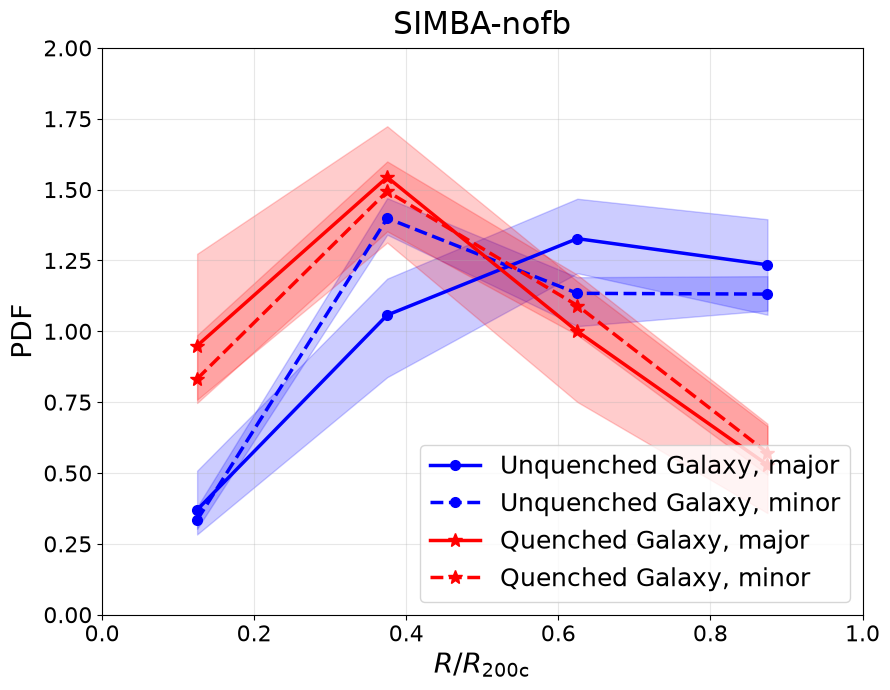

In [12]:
part_type = 'star_axis'

ITM = False
N_load = 50
sample_angle = 45 # [deg]
redshift = 0.0

snapnum = 151

UnQgal_major_collection = []
UnQgal_minor_collection = []

Qgal_major_collection = []
Qgal_minor_collection = []

for suffix in range(N_load):
    Full_snap = np.load('/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/SIMBAm50n512/nofb/data/GalInHalo_' + part_type + f'/{snapnum:03}/galaxy_' + f'{suffix}' + '.npy')

    mask_cgal = Full_snap[:, 8] == Full_snap[:, 9]
    cgal_data = Full_snap[mask_cgal, :]
    mask_cgal_M200c = (cgal_data[:, 32] >= 1e12)
    mask_cgal_M = mask_cgal_M200c
    cgal_M_data = cgal_data[mask_cgal_M, :]

    with open(f'cluster_data/SIMBAnofb/{snapnum:03}/all' + f'_data.pkl', 'rb') as f:
        axis_align_data = pickle.load(f)

    # cgalCID, [angle_1, angle_2, angle_3], vec_star(3*3), vec_dm(3*3)
    cgal_axis_state = np.array([sublist[0] for sublist in axis_align_data])

    mask_axis_state = np.isin(cgal_M_data[:, 9], cgal_axis_state)
    cgal_M_data = cgal_M_data[mask_axis_state]

    mask_sgal = np.isin(Full_snap[:, 9], cgal_M_data[:, 9]) & (Full_snap[:, 8] != Full_snap[:, 9]) & (Full_snap[:, 7] >= 10**(9.5)) & (Full_snap[:, 3] < Full_snap[:, 17])
    sgaldata = Full_snap[mask_sgal, :]

    UnQgal_major, UnQgal_minor, Qgal_major, Qgal_minor = UnQ_Q_Selection(sgaldata)
    
    UnQgal_major_collection.append(UnQgal_major)
    UnQgal_minor_collection.append(UnQgal_minor)
    
    Qgal_major_collection.append(Qgal_major)
    Qgal_minor_collection.append(Qgal_minor)
    

UnQgal_major_RR200c = []
for arr in UnQgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_major_RR200c.append(ratio)
    
UnQgal_minor_RR200c = []
for arr in UnQgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_minor_RR200c.append(ratio)

Qgal_major_RR200c = []
for arr in Qgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_major_RR200c.append(ratio)

Qgal_minor_RR200c = []
for arr in Qgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_minor_RR200c.append(ratio)
    

    
    
bins = np.linspace(0, 1, 5)  

plt.figure(figsize=(9, 7))


# === 1. UnQgal_major_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_major_RR200c, bins,
    color='blue', marker='o', linestyle='-',
    markersize=7, label='Unquenched Galaxy, major'
)

# === 2. UnQgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_minor_RR200c, bins,
    color='blue', marker='o', linestyle='--',
    markersize=7, label='Unquenched Galaxy, minor'
)

# === 3. Qgal_major_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_major_RR200c, bins,
    color='red', marker='*', linestyle='-',
    markersize=10, label='Quenched Galaxy, major'
)

# === 4. Qgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_minor_RR200c, bins,
    color='red', marker='*', linestyle='--',
    markersize=10, label='Quenched Galaxy, minor'
)

plt.xlim(0, 1)
plt.ylim(0, 2)
plt.xticks(fontsize=16)  
plt.yticks(fontsize=16)  
plt.xlabel(r'$R/R_\mathrm{200c}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.title('SIMBA-nofb', fontsize=22, pad=10)
plt.legend(fontsize=18, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_result/SIMBAnofb_UnQ_Q_R.pdf')
plt.show()

# [Fig. 3]TNG100

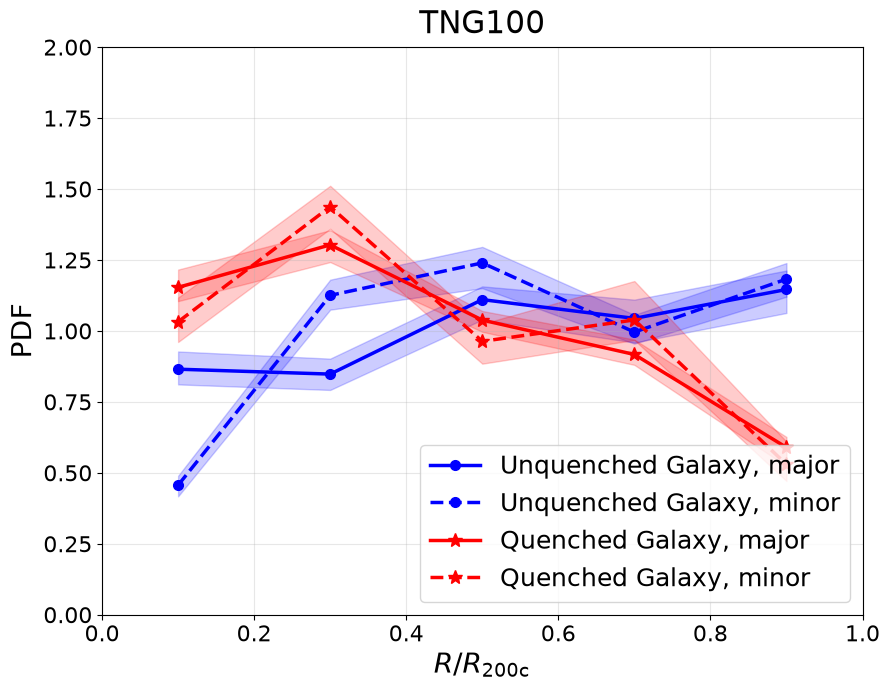

In [13]:
part_type = 'star_axis'

ITM = False
N_load = 50
sample_angle = 45 # [deg]
redshift = 0.0

snapnum = '099'

UnQgal_major_collection = []
UnQgal_minor_collection = []

Qgal_major_collection = []
Qgal_minor_collection = []

for suffix in range(N_load):
    Full_snap = np.load('/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/TNG100/data/GalInHalo_' + part_type + f'/{snapnum:03}/galaxy_' + f'{suffix}' + '.npy')

    mask_cgal = Full_snap[:, 8] == Full_snap[:, 9]
    cgal_data = Full_snap[mask_cgal, :]
    mask_cgal_M200c = (cgal_data[:, 32] >= 1e12)
    mask_cgal_M = mask_cgal_M200c
    cgal_M_data = cgal_data[mask_cgal_M, :]

    with open(f'cluster_data/TNG100/{snapnum:03}/all' + f'_data.pkl', 'rb') as f:
        axis_align_data = pickle.load(f)

    # cgalCID, [angle_1, angle_2, angle_3], vec_star(3*3), vec_dm(3*3)
    cgal_axis_state = np.array([sublist[0] for sublist in axis_align_data])

    mask_axis_state = np.isin(cgal_M_data[:, 9], cgal_axis_state)
    cgal_M_data = cgal_M_data[mask_axis_state]

    mask_sgal = np.isin(Full_snap[:, 9], cgal_M_data[:, 9]) & (Full_snap[:, 8] != Full_snap[:, 9]) & (Full_snap[:, 7] >= 10**(9.5)) & (Full_snap[:, 3] < Full_snap[:, 17])
    sgaldata = Full_snap[mask_sgal, :]

    UnQgal_major, UnQgal_minor, Qgal_major, Qgal_minor = UnQ_Q_Selection(sgaldata)
    
    UnQgal_major_collection.append(UnQgal_major)
    UnQgal_minor_collection.append(UnQgal_minor)
    
    Qgal_major_collection.append(Qgal_major)
    Qgal_minor_collection.append(Qgal_minor)
    

UnQgal_major_RR200c = []
for arr in UnQgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_major_RR200c.append(ratio)

UnQgal_minor_RR200c = []
for arr in UnQgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_minor_RR200c.append(ratio)

Qgal_major_RR200c = []
for arr in Qgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_major_RR200c.append(ratio)

Qgal_minor_RR200c = []
for arr in Qgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_minor_RR200c.append(ratio)
    


# ------------------------------------------------------------------------------
bins = np.linspace(0, 1, 6)  

# Plot
plt.figure(figsize=(9, 7))

# === 1. UnQgal_major_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_major_RR200c, bins,
    color='blue', marker='o', linestyle='-',
    markersize=7, label='Unquenched Galaxy, major'
)

# === 2. UnQgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_minor_RR200c, bins,
    color='blue', marker='o', linestyle='--',
    markersize=7, label='Unquenched Galaxy, minor'
)

# === 3. Qgal_major_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_major_RR200c, bins,
    color='red', marker='*', linestyle='-',
    markersize=10, label='Quenched Galaxy, major'
)

# === 4. Qgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_minor_RR200c, bins,
    color='red', marker='*', linestyle='--',
    markersize=10, label='Quenched Galaxy, minor'
)


plt.xlim(0, 1)
plt.ylim(0, 2)
plt.xticks(fontsize=16)  
plt.yticks(fontsize=16)  
plt.xlabel(r'$R/R_\mathrm{200c}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.title('TNG100', fontsize=22, pad=10)
plt.legend(fontsize=18, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_result/TNG100_UnQ_Q_R.pdf')
plt.show()

# [Fig. 3]EAGLE

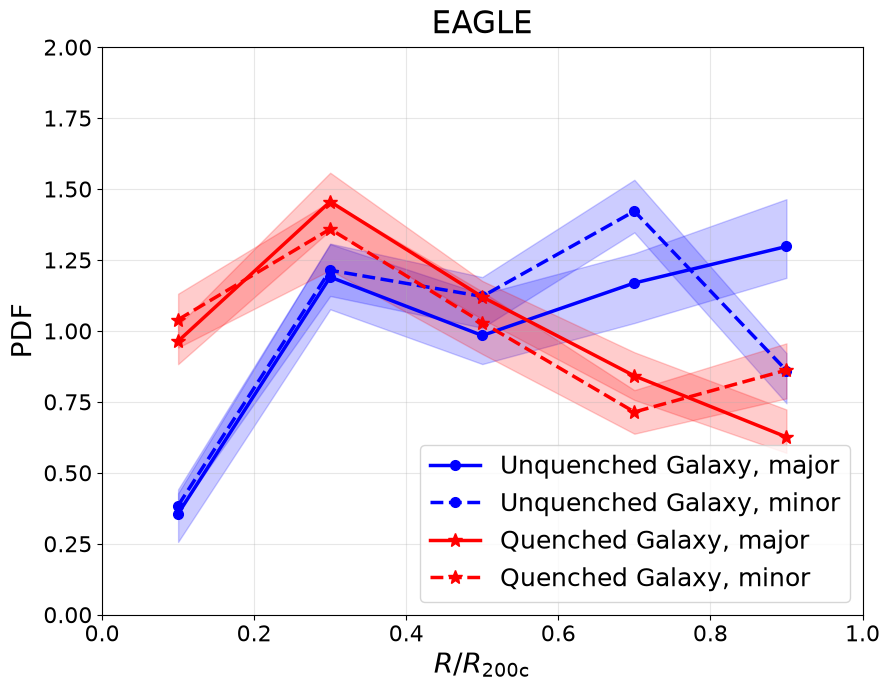

In [14]:
part_type = 'star_axis'

ITM = False
N_load = 50
sample_angle = 45 # [deg]
redshift = 0.0

snapnum = '028_z000p000'

UnQgal_major_collection = []
UnQgal_minor_collection = []

Qgal_major_collection = []
Qgal_minor_collection = []

for suffix in range(N_load):
    Full_snap = np.load('/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/EAGLE/data/GalInHalo_' + part_type + f'/{snapnum:03}/galaxy_' + f'{suffix}' + '.npy')

    mask_cgal = Full_snap[:, 8] == Full_snap[:, 9]
    cgal_data = Full_snap[mask_cgal, :]
    mask_cgal_M200c = (cgal_data[:, 32] >= 1e12)
    mask_cgal_M = mask_cgal_M200c
    cgal_M_data = cgal_data[mask_cgal_M, :]

    with open(f'cluster_data/EAGLE/{snapnum:03}/all' + f'_data.pkl', 'rb') as f:
        axis_align_data = pickle.load(f)

    # cgalCID, [angle_1, angle_2, angle_3], vec_star(3*3), vec_dm(3*3)
    cgal_axis_state = np.array([sublist[0] for sublist in axis_align_data])

    mask_axis_state = np.isin(cgal_M_data[:, 9], cgal_axis_state)
    cgal_M_data = cgal_M_data[mask_axis_state]

    mask_sgal = np.isin(Full_snap[:, 9], cgal_M_data[:, 9]) & (Full_snap[:, 8] != Full_snap[:, 9]) & (Full_snap[:, 7] >= 10**(9.5)) & (Full_snap[:, 3] < Full_snap[:, 17])
    sgaldata = Full_snap[mask_sgal, :]

    UnQgal_major, UnQgal_minor, Qgal_major, Qgal_minor = UnQ_Q_Selection(sgaldata)
    
    UnQgal_major_collection.append(UnQgal_major)
    UnQgal_minor_collection.append(UnQgal_minor)
    
    Qgal_major_collection.append(Qgal_major)
    Qgal_minor_collection.append(Qgal_minor)
    

UnQgal_major_RR200c = []
for arr in UnQgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_major_RR200c.append(ratio)

UnQgal_minor_RR200c = []
for arr in UnQgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_minor_RR200c.append(ratio)

Qgal_major_RR200c = []
for arr in Qgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_major_RR200c.append(ratio)

Qgal_minor_RR200c = []
for arr in Qgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_minor_RR200c.append(ratio)
    


# ------------------------------------------------------------------------------
bins = np.linspace(0, 1, 6)  

# Plot
plt.figure(figsize=(9, 7))

# === 1. UnQgal_major_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_major_RR200c, bins,
    color='blue', marker='o', linestyle='-',
    markersize=7, label='Unquenched Galaxy, major'
)

# === 2. UnQgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_minor_RR200c, bins,
    color='blue', marker='o', linestyle='--',
    markersize=7, label='Unquenched Galaxy, minor'
)

# === 3. Qgal_major_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_major_RR200c, bins,
    color='red', marker='*', linestyle='-',
    markersize=10, label='Quenched Galaxy, major'
)

# === 4. Qgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_minor_RR200c, bins,
    color='red', marker='*', linestyle='--',
    markersize=10, label='Quenched Galaxy, minor'
)

# ------------------------------------------------------------------------------
plt.xlim(0, 1)
plt.ylim(0, 2)
plt.xticks(fontsize=16)  
plt.yticks(fontsize=16)  
plt.xlabel(r'$R/R_\mathrm{200c}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.title('EAGLE', fontsize=22, pad=10)
plt.legend(fontsize=18, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_result/EAGLE_UnQ_Q_R.pdf')
plt.show()

# [Fig. 7]TNG100: lowmass

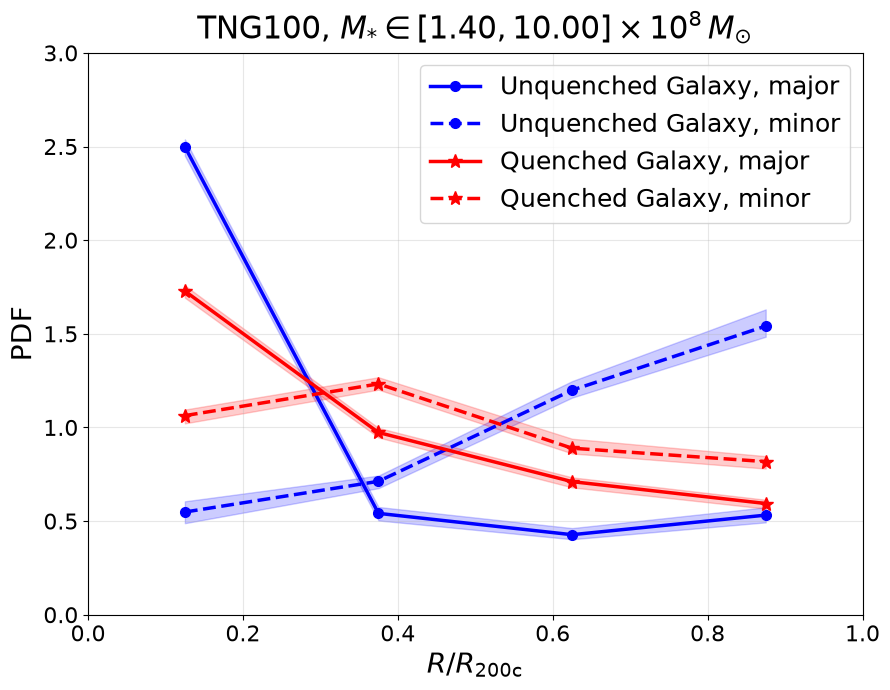

In [15]:
part_type = 'star_axis'

ITM = False
N_load = 50
sample_angle = 45 # [deg]
redshift = 0.0

snapnum = '099'

UnQgal_major_collection = []
UnQgal_minor_collection = []

Qgal_major_collection = []
Qgal_minor_collection = []

for suffix in range(N_load):
    Full_snap = np.load('/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/TNG100/data/GalInHalo_' + part_type + f'/{snapnum:03}/galaxy_' + f'{suffix}' + '.npy')

    mask_cgal = Full_snap[:, 8] == Full_snap[:, 9]
    cgal_data = Full_snap[mask_cgal, :]
    mask_cgal_M200c = (cgal_data[:, 32] >= 1e12)
    mask_cgal_M = mask_cgal_M200c
    cgal_M_data = cgal_data[mask_cgal_M, :]

    with open(f'cluster_data/TNG100/{snapnum:03}/all' + f'_data.pkl', 'rb') as f:
        axis_align_data = pickle.load(f)

    # cgalCID, [angle_1, angle_2, angle_3], vec_star(3*3), vec_dm(3*3)
    cgal_axis_state = np.array([sublist[0] for sublist in axis_align_data])

    mask_axis_state = np.isin(cgal_M_data[:, 9], cgal_axis_state)
    cgal_M_data = cgal_M_data[mask_axis_state]

    mask_sgal = np.isin(Full_snap[:, 9], cgal_M_data[:, 9]) & (Full_snap[:, 8] != Full_snap[:, 9]) & (Full_snap[:, 7] >= 1.40 * 10**(8)) & (Full_snap[:, 7] <= 10**(9)) & (Full_snap[:, 3] < Full_snap[:, 17])
    sgaldata = Full_snap[mask_sgal, :]

    UnQgal_major, UnQgal_minor, Qgal_major, Qgal_minor = UnQ_Q_Selection(sgaldata)
    
    UnQgal_major_collection.append(UnQgal_major)
    UnQgal_minor_collection.append(UnQgal_minor)
    
    Qgal_major_collection.append(Qgal_major)
    Qgal_minor_collection.append(Qgal_minor)
    

UnQgal_major_RR200c = []
for arr in UnQgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_major_RR200c.append(ratio)

UnQgal_minor_RR200c = []
for arr in UnQgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_minor_RR200c.append(ratio)

Qgal_major_RR200c = []
for arr in Qgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_major_RR200c.append(ratio)

Qgal_minor_RR200c = []
for arr in Qgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_minor_RR200c.append(ratio)
    


# ------------------------------------------------------------------------------
bins = np.linspace(0, 1, 5)  

# Plot
plt.figure(figsize=(9, 7))

# === 1. UnQgal_major_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_major_RR200c, bins,
    color='blue', marker='o', linestyle='-',
    markersize=7, label='Unquenched Galaxy, major'
)

# === 2. UnQgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_minor_RR200c, bins,
    color='blue', marker='o', linestyle='--',
    markersize=7, label='Unquenched Galaxy, minor'
)

# === 3. Qgal_major_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_major_RR200c, bins,
    color='red', marker='*', linestyle='-',
    markersize=10, label='Quenched Galaxy, major'
)

# === 4. Qgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_minor_RR200c, bins,
    color='red', marker='*', linestyle='--',
    markersize=10, label='Quenched Galaxy, minor'
)


plt.xlim(0, 1)
plt.ylim(0, 3)
plt.xticks(fontsize=16)  
plt.yticks(fontsize=16)  
plt.xlabel(r'$R/R_\mathrm{200c}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.title('TNG100, ' + r'$M_{*} \in [1.40, 10.00]  \times 10^{8}\, M_{\odot}$', fontsize=22, pad=10)
plt.legend(fontsize=18, loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_result/TNG100_lowmass_UnQ_Q_R.pdf')
plt.show()

# [Fig. 7]EAGLE: lowmass

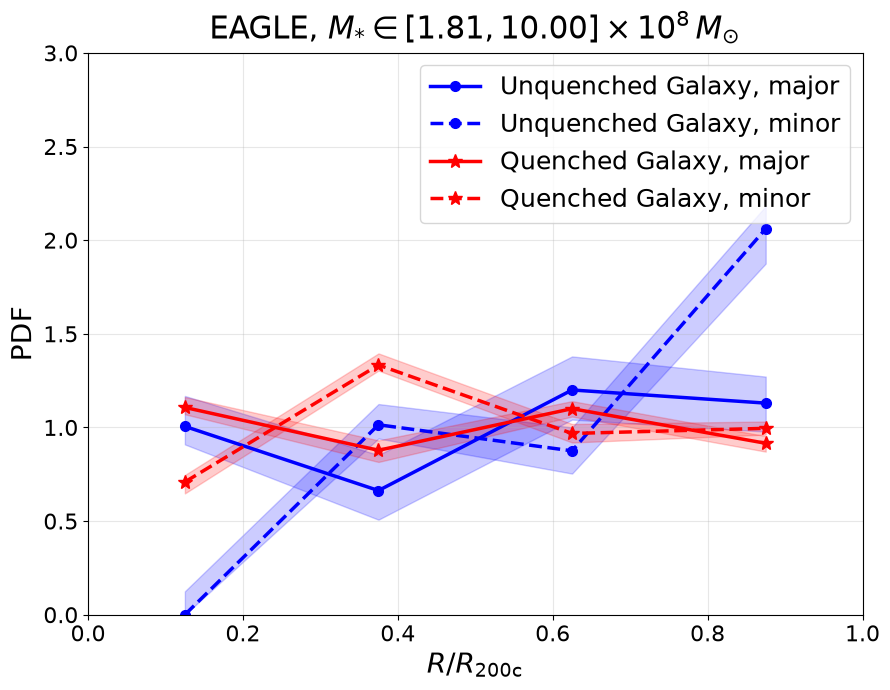

In [16]:
part_type = 'star_axis'

ITM = False
N_load = 50
sample_angle = 45 # [deg]
redshift = 0.0

snapnum = '028_z000p000'

UnQgal_major_collection = []
UnQgal_minor_collection = []

Qgal_major_collection = []
Qgal_minor_collection = []

for suffix in range(N_load):
    Full_snap = np.load('/data/inspur_disk06/userdir/zhangzhuoming/Quench_Direction_Data/EAGLE/data/GalInHalo_' + part_type + f'/{snapnum:03}/galaxy_' + f'{suffix}' + '.npy')

    mask_cgal = Full_snap[:, 8] == Full_snap[:, 9]
    cgal_data = Full_snap[mask_cgal, :]
    mask_cgal_M200c = (cgal_data[:, 32] >= 1e12)
    mask_cgal_M = mask_cgal_M200c
    cgal_M_data = cgal_data[mask_cgal_M, :]

    with open(f'cluster_data/EAGLE/{snapnum:03}/all' + f'_data.pkl', 'rb') as f:
        axis_align_data = pickle.load(f)

    # cgalCID, [angle_1, angle_2, angle_3], vec_star(3*3), vec_dm(3*3)
    cgal_axis_state = np.array([sublist[0] for sublist in axis_align_data])

    mask_axis_state = np.isin(cgal_M_data[:, 9], cgal_axis_state)
    cgal_M_data = cgal_M_data[mask_axis_state]

    mask_sgal = np.isin(Full_snap[:, 9], cgal_M_data[:, 9]) & (Full_snap[:, 8] != Full_snap[:, 9]) & (Full_snap[:, 7] >= 1.81 * 10**(8)) & (Full_snap[:, 7] <= 10**(9)) & (Full_snap[:, 3] < Full_snap[:, 17])
    sgaldata = Full_snap[mask_sgal, :]

    UnQgal_major, UnQgal_minor, Qgal_major, Qgal_minor = UnQ_Q_Selection(sgaldata)
    
    UnQgal_major_collection.append(UnQgal_major)
    UnQgal_minor_collection.append(UnQgal_minor)
    
    Qgal_major_collection.append(Qgal_major)
    Qgal_minor_collection.append(Qgal_minor)
    

UnQgal_major_RR200c = []
for arr in UnQgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_major_RR200c.append(ratio)

UnQgal_minor_RR200c = []
for arr in UnQgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    UnQgal_minor_RR200c.append(ratio)

Qgal_major_RR200c = []
for arr in Qgal_major_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_major_RR200c.append(ratio)

Qgal_minor_RR200c = []
for arr in Qgal_minor_collection:
    ratio = arr[:, 3] / arr[:, 17]
    Qgal_minor_RR200c.append(ratio)
    


# ------------------------------------------------------------------------------
bins = np.linspace(0, 1, 5)  

# Plot
plt.figure(figsize=(9, 7))

# === 1. UnQgal_major_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_major_RR200c, bins,
    color='blue', marker='o', linestyle='-',
    markersize=7, label='Unquenched Galaxy, major'
)

# === 2. UnQgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    UnQgal_minor_RR200c, bins,
    color='blue', marker='o', linestyle='--',
    markersize=7, label='Unquenched Galaxy, minor'
)

# === 3. Qgal_major_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_major_RR200c, bins,
    color='red', marker='*', linestyle='-',
    markersize=10, label='Quenched Galaxy, major'
)

# === 4. Qgal_minor_RR200c ===
plot_distribution_with_uncertainty(
    Qgal_minor_RR200c, bins,
    color='red', marker='*', linestyle='--',
    markersize=10, label='Quenched Galaxy, minor'
)

# ------------------------------------------------------------------------------
plt.xlim(0, 1)
plt.ylim(0, 3)
plt.xticks(fontsize=16)  
plt.yticks(fontsize=16)  
plt.xlabel(r'$R/R_\mathrm{200c}$', fontsize=20)
plt.ylabel('PDF', fontsize=20)
plt.title('EAGLE, ' + r'$M_{*} \in [1.81, 10.00]  \times 10^{8}\, M_{\odot}$', fontsize=22, pad=10)
plt.legend(fontsize=18, loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_result/EAGLE_lowmass_UnQ_Q_R.pdf')
plt.show()